<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span><strong>Описание проекта</strong></a></span><ul class="toc-item"><li><span><a href="#План-работы" data-toc-modified-id="План-работы-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>План работы</a></span></li><li><span><a href="#Описание-данных" data-toc-modified-id="Описание-данных-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Описание данных</a></span></li></ul></li><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span><strong>Загрузка данных</strong></a></span></li><li><span><a href="#Умножение-матриц" data-toc-modified-id="Умножение-матриц-3"><span class="toc-item-num">3&nbsp;&nbsp;</span><strong>Умножение матриц</strong></a></span></li><li><span><a href="#Алгоритм-преобразования-данных" data-toc-modified-id="Алгоритм-преобразования-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span><strong>Алгоритм преобразования данных</strong></a></span><ul class="toc-item"><li><span><a href="#Выделим-признаки-и-целевой-признак-в-исходных-данных" data-toc-modified-id="Выделим-признаки-и-целевой-признак-в-исходных-данных-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Выделим признаки и целевой признак в исходных данных</a></span></li><li><span><a href="#Создаем-обратимую-матрицу" data-toc-modified-id="Создаем-обратимую-матрицу-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Создаем обратимую матрицу</a></span></li><li><span><a href="#Преобразуем-исходные-признаки" data-toc-modified-id="Преобразуем-исходные-признаки-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Преобразуем исходные признаки</a></span></li><li><span><a href="#Подготовим-данные-для-обучения-и-тестирования-модели" data-toc-modified-id="Подготовим-данные-для-обучения-и-тестирования-модели-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Подготовим данные для обучения и тестирования модели</a></span></li><li><span><a href="#Проверка-качества-модели" data-toc-modified-id="Проверка-качества-модели-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>Проверка качества модели</a></span></li></ul></li><li><span><a href="#Результаты" data-toc-modified-id="Результаты-5"><span class="toc-item-num">5&nbsp;&nbsp;</span><strong>Результаты</strong></a></span></li></ul></div>

# Защита персональных данных клиентов страховой компании

## **Описание проекта**

Нам нужно защитить данные клиентов страховой компании «Хоть потоп». 


Задача: разработать такой метод преобразования данных, чтобы 
- по ним было сложно восстановить персональную информацию
- при преобразовании качество моделей машинного обучения не ухудшилось.

Необходимо обосновать корректность его работы. Подбирать наилучшую модель не требуется.



### План работы

1. Загрузить и изучить данные.



2. Ответить на вопрос и обосновать решение. 

 ❓ Если признаки умножить на обратимую матрицу, изменится ли качество линейной регрессии? (её можно обучить заново)
 
 a. Изменится. Привести примеры матриц.
 
 b. Не изменится. Указать, как связаны параметры линейной регрессии в исходной задаче и в преобразованной.
 
 
3. Предложить алгоритм преобразования данных для решения задачи. Обосновать, почему качество линейной регрессии не поменяется.



4. Запрограммировать этот алгоритм, применив матричные операции. Проверить, что качество линейной регрессии из sklearn не отличается до и после преобразования. Метрика оценки - R2.

### Описание данных


**Признаки**: пол, возраст и зарплата застрахованного, количество членов его семьи.


**Целевой признак**: количество страховых выплат клиенту за последние 5 лет.

In [1]:
import pandas as pd
import numpy as np

from ydata_profiling import ProfileReport

from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_spd_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from scipy.stats import mannwhitneyu

import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

import warnings
warnings.simplefilter(action='ignore')

## **Загрузка данных**

In [2]:
try:
    insurance = pd.read_csv('C:\\Users\\1\\Downloads\\insurance.csv')
    
except:  
    insurance = pd.read_csv('/datasets/insurance.csv')

In [3]:
# полный отчет о данных

ProfileReport(insurance, title = 'Отчет о данных страховой компании', explorative=True)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

- **5 000 наблюдений, 5 переменных**: Пол - категориальная (тип int64); Возраст, Зарплата - вещественные (тип float64), Члены семьи, Страховые выплаты - целочисленные (тип int64).



- **Пол**: два значения 0 - 50.1% и 1 - 49.9%;



- **Возраст**: минимальное значение 18, максимальное значение 65;



- **Зарплата**: минимальное значение 5 300, максимальное значение 79 000, нулевых значений нет;



- **Члены семьи**: минимальное значение 0, максимальное значение 6, чаще всего это одинокие клиенты (30.3%) или +1 член семьи (36.3%);


- **Страховые выплаты**: минимальное значение 0 - 88.7%, максимальное значение 5 < 0.1%;



- **пропусков нет**; 



- **дубликатов** 147 строк или 2.9%;



- средняя, по шкале Чеддока, **корреляция** между Возрастом и Страховыми выплатами.

In [4]:
# образец данных

insurance.head()

,Пол,Возраст,Зарплата,Члены семьи,Страховые выплаты
0,1,41.0,49600.0,1,0
1,0,46.0,38000.0,1,1
2,0,29.0,21000.0,0,0
3,0,21.0,41700.0,2,0
4,1,28.0,26100.0,0,0


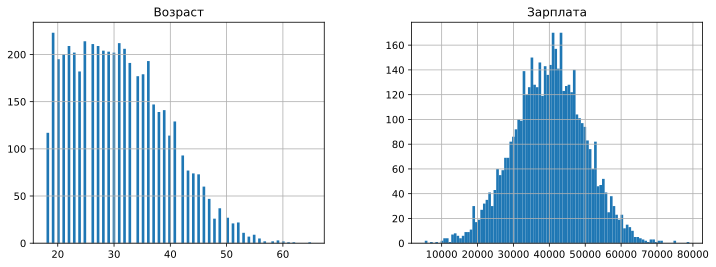

In [5]:
# распределение численных признаков датасета

insurance[['Возраст', 'Зарплата']].hist(figsize=(12, 4), bins = 100);  

In [6]:
# распределение категориальных признаков
# так как количество членов семьи, большее 3 намного меньше у подавляющего числа клиентов, 
# отнесем их в категорию "другие" для удобства визуализации, так же и со страховыми выплатами более одной
sample = insurance.copy()

sample.loc[sample['Члены семьи'] > 3, 'Члены семьи'] = 'более 3х'
sample.loc[sample['Страховые выплаты'] > 1, 'Страховые выплаты'] = 'более 1й'

In [7]:
def plot_pie(feature):
    plt.pie(sample[feature].value_counts(), 
            labels=sample[feature].value_counts().index, 
            colors=sns.color_palette('Spectral'), 
            autopct='%.1f%%')
    plt.title(feature);

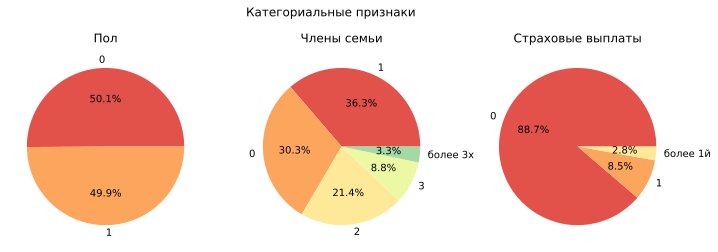

In [8]:
plt.figure(figsize=(12, 4))
    
plt.subplot(1, 3, 1)
plot_pie('Пол')
     
plt.subplot(1, 3, 2)
plot_pie('Члены семьи')
    
plt.subplot(1, 3, 3)
plot_pie('Страховые выплаты')

plt.suptitle('Категориальные признаки')
plt.show()

del sample

## **Умножение матриц**

Ответим на вопрос и обоснуем решение.

Признаки умножают на обратимую матрицу. Изменится ли качество линейной регрессии? 

a. Изменится. Примеры матриц.

b. Не изменится. Связь параметров линейной регрессии в исходной задаче и в преобразованной.

Обозначения:

- $X$ — матрица признаков (нулевой столбец состоит из единиц)

- $y$ — вектор целевого признака

- $P$ — матрица, на которую умножаются признаки

- $w$ — вектор весов линейной регрессии (нулевой элемент равен сдвигу)

- $XP$ — новая матрица признаков

Предсказания:

$$
a = Xw
$$

Задача обучения:

$$
w = \arg\min_w MSE(Xw, y)
$$

Формула обучения:

$$
w = (X^T X)^{-1} X^T y
$$

Докажем теоретическим путем, что предсказания модели для новой матрицы не изменятся.

Для доказательства воспользуемся следующими свойствами матриц:

- умножение обратимой матрицы на обратную равно единичной матрице $PP^{-1} = E$ 

- обратная матрица произведения матриц $(AB)^{-1} = B^{-1}A^{-1}$

- транспонированная матрица произведения матриц $(AB)^T = B^TA^T$

- если любую матрицу умножить на единичную (или наоборот), получится эта же матрица $AE = EA = A$

Подставим в формулу для предсказаний новую матрицу и вектор весов, уравнение для которого приведено выше в формуле обучения, и преобразуем это выражение:

$$
новые \; предсказания = XP \; (\;(XP)^T(XP)\;)^{-1}(XP)^Ty = 
$$

$$
= XP\;(P^TX^TXP)^{-1}\;P^TX^T\;y = 
$$

$$
= XP\;(P^T\;(X^TX)\;P)^{-1}P^TX^T\;y =
$$

$$
= XP\;P^{-1}(X^TX)^{-1}\;(P^T)^{-1}\;P^TX^T\;y = 
$$

$$
= X\;(X^TX)^{-1}\;X^T\;y = \; a = \; исходные \;предсказания
$$

Теперь получим  подтверждение эмпирическим путем.

## **Алгоритм преобразования данных**

### Выделим признаки и целевой признак в исходных данных

In [9]:
X = insurance.drop('Страховые выплаты', axis=1)
y = insurance['Страховые выплаты']

print('Размер признаков         :', X.shape)
print('Размер целевого признака :', y.shape)

Размер признаков         : (5000, 4)
Размер целевого признака : (5000,)


### Создаем обратимую матрицу

Для преобразования исходных признаков нам нужна случайна обратимая матрица, размерность которой равна количеству признаков исходных данных.

Для создания матрицы воспользуемся методом [sklearn.datasets.make_spd_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_spd_matrix.html)

In [10]:
n = X.shape[1]

In [11]:
P = make_spd_matrix(n_dim = n, random_state = 0)

P

array([[ 1.00665013, -1.41434036, -0.4953264 , -0.43520063],
       [-1.41434036,  3.81637179,  0.58656485,  0.5053143 ],
       [-0.4953264 ,  0.58656485,  0.87865608,  0.00746661],
       [-0.43520063,  0.5053143 ,  0.00746661,  0.79932913]])

Проверим матрицу на обратимость:

In [12]:
try:
    np.linalg.inv(P)
    print('Матрица обратимая!')
    
except:
    print('Матрица необратимая, нужна другая!')

Матрица обратимая!


### Преобразуем исходные признаки

In [13]:
X_new = X @ P

print('Размер новых признаков :', X_new.shape)

Размер новых признаков : (5000, 4)


### Подготовим данные для обучения и тестирования модели

In [14]:
def split(X, y):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
    
    print('Размер обучающей выборки :', X_train.shape)
    print('Размер целевого признака :', y_train.shape)
    print()
    print('Размер тестовой выборки  :', X_test.shape)
    print('Размер целевого признака :', y_test.shape)
    
    return X_train, X_test, y_train, y_test

In [15]:
X_train, X_test, y_train, y_test = split(X, y)

Размер обучающей выборки : (3750, 4)
Размер целевого признака : (3750,)

Размер тестовой выборки  : (1250, 4)
Размер целевого признака : (1250,)


In [16]:
X_train_new, X_test_new, y_train_new, y_test_new = split(X_new, y)

Размер обучающей выборки : (3750, 4)
Размер целевого признака : (3750,)

Размер тестовой выборки  : (1250, 4)
Размер целевого признака : (1250,)


### Проверка качества модели

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)
predictions = lr.predict(X_test)

print('Метрика качества модели R2 для исходных признаков =', r2_score(y_test, predictions))

Метрика качества модели R2 для исходных признаков = 0.3878739635059181


In [18]:
lr = LinearRegression()
lr.fit(X_train_new, y_train_new)
predictions_new = lr.predict(X_test_new)

print('Метрика качества модели R2 для измененных признаков =', r2_score(y_test_new, predictions_new))

Метрика качества модели R2 для измененных признаков = 0.38787396350578573


In [19]:
print('Разница в метриках качества R2 между исходными и измененными признаками составляет :', 
      r2_score(y_test, predictions) - r2_score(y_test_new, predictions_new))

Разница в метриках качества R2 между исходными и измененными признаками составляет : 1.3233858453531866e-13


Есть незначительные отличия, которые вызваны особенностью преобразования матриц и чисел с плавающей точкой.

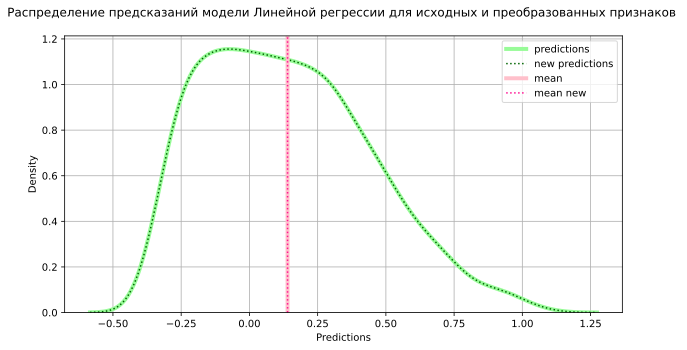

In [20]:
plt.figure(figsize=(10, 5))

sns.kdeplot(predictions, 
            label='predictions', 
            color='palegreen', 
            linewidth=4) 

sns.kdeplot(predictions_new,
            label='new predictions', 
            color='darkgreen',
            linestyle=':')

plt.axvline(x=predictions.mean(), 
            color='pink', 
            label='mean', 
            linewidth=4)

plt.axvline(x=predictions_new.mean(), 
            color='deeppink', 
            linestyle=':', 
            label='mean new')

plt.legend(fontsize=10)
plt.grid()
plt.title('Распределение предсказаний модели Линейной регрессии для исходных и преобразованных признаков \n')
plt.xlabel('Predictions')
plt.show()

По графику распределений видно, что они одинаковы. 

Сравним распределения с помощью **U-теста Манна-Уитни**:

H0 - Распределения предсказаний модели Линейной регрессии для исходных и преобразованных признаков одинаковые.

H1 - Распределения предсказаний модели Линейной регрессии для исходных и преобразованных признаков разные.

In [21]:
_, p = mannwhitneyu(predictions, predictions_new)

print('p=%.3f'%p)

alpha = 0.05

if p > alpha:
    print('Распределения одинаковые (нет достаточных оснований, чтобы отклонить H0)')
    
else:
    print('Распределения разные (есть достаточно оснований, чтобы отклонить H0)')

p=0.972
Распределения одинаковые (нет достаточных оснований, чтобы отклонить H0)


## **Результаты**

Признаки можно умножать на **обратимую матрицу** для шифрования, и, таким образом, защиты персональных данных клиентов. При таком преобразовании признаков качество моделей машинного обучения не ухудшится.


